# Forecasting NOK/USD from the oil-futures term structure

This notebook is a **readable narrative** on top of the modular code in `src/`.
Each analysis step calls a `src` module (which can also be run standalone from
the terminal) and explains what and why along the way.

**Data source:** local Datastream/Refinitiv extracts — the real ICE Brent term
structure `TRc1`–`TRc12` (full 1–12 month curve) and NOK/USD, monthly 2001–2021.

**Goal:** test whether the *shape* of the term structure (compressed into the
Diebold–Li factors level/slope/curvature) can forecast the **NOK/USD return**
better than a naive random walk — under two out-of-sample windowing schemes
(expanding and rolling).

In [1]:
import sys
from pathlib import Path

# Make src/ importable whether the notebook runs from the root or notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import config

def show(*names):
    for n in names:
        display(Image(filename=str(config.OUTPUT_DIR / n)))

def show_csv(name, index_col=0):
    return pd.read_csv(config.OUTPUT_DIR / name, index_col=index_col)

## Step 1 — Data acquisition and alignment

We read NOK/USD and the Brent term structure through the modular `data_loader`
interface and align them on a common monthly date index. `M1` (front-month) is
the "first nearby". The result is 243 complete months with no gaps.

In [2]:
from src.data_acquisition import build_dataset
df = build_dataset()
df.head()

[data] Term-structure source: Excel: ICE Brent TRc1-TRc12 (real, full 1-12 curve, monthly)
[data] FX: NOKUSD  (2001-01-31 -> 2021-03-31)
[data] Maturities: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
[data] 243 months before align -> 243 complete months (2001-01-31 -> 2021-03-31)
[data] Saved to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\dataset.parquet


,NOKUSD,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12
date,,,,,,,,,,,,,
2001-01-31,0.114055,26.66,25.71,25.46,25.22,25.00,24.77,24.53,24.30,24.09,23.89,23.60,23.35
2001-02-28,0.112199,25.57,25.71,25.71,25.53,25.31,25.11,24.91,24.71,24.49,24.15,23.91,23.61
2001-03-31,0.109105,24.74,24.92,24.85,24.74,24.60,24.45,24.30,24.13,23.89,23.69,23.49,23.25
2001-04-30,0.110216,27.89,27.66,27.28,27.01,26.73,26.44,26.13,25.82,25.52,25.22,24.92,24.62
2001-05-31,0.106720,29.34,28.00,27.53,27.23,26.93,26.60,26.24,25.92,25.59,25.26,24.95,24.69


## Step 2 — Exploratory analysis

Three questions before modelling: (1) Do the krone and oil move together?
(2) Is the relationship stable? (3) What does the term structure look like?

We compute correlation on **monthly changes** (not levels), since two trending
level series easily give an artificially high correlation.

[eda] 243 monthly observations (2001-01-31 -> 2021-03-31)
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_nokusd_vs_frontmonth.png
[eda] Correlation (returns) NOK/USD vs Brent M1: 0.532


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_rolling_corr_60m.png
[eda] Rolling corr: mean 0.54, min 0.06, max 0.72
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\02_term_structure_3d.png


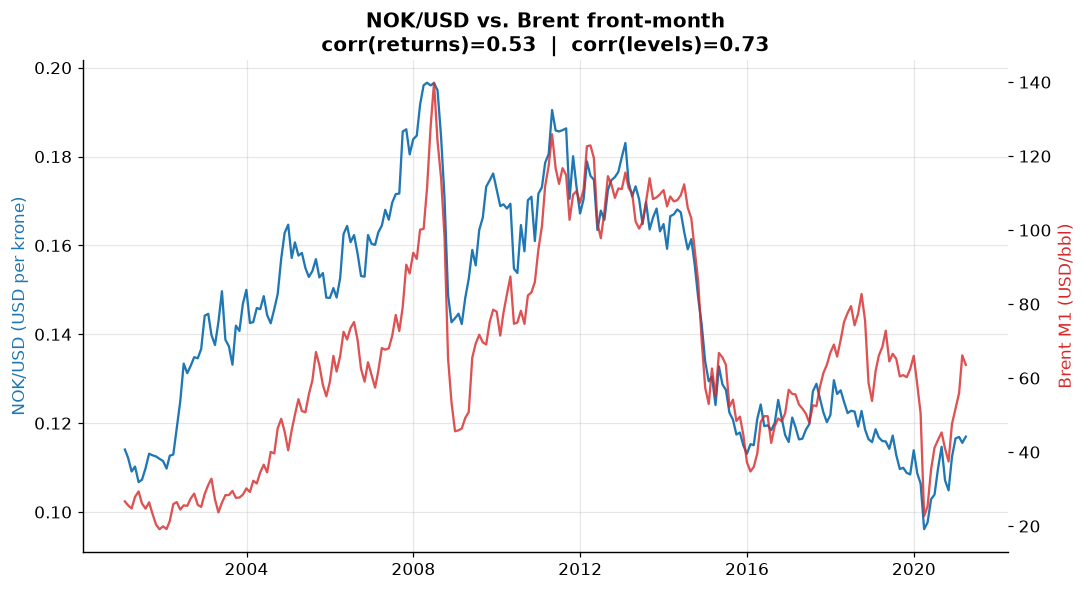

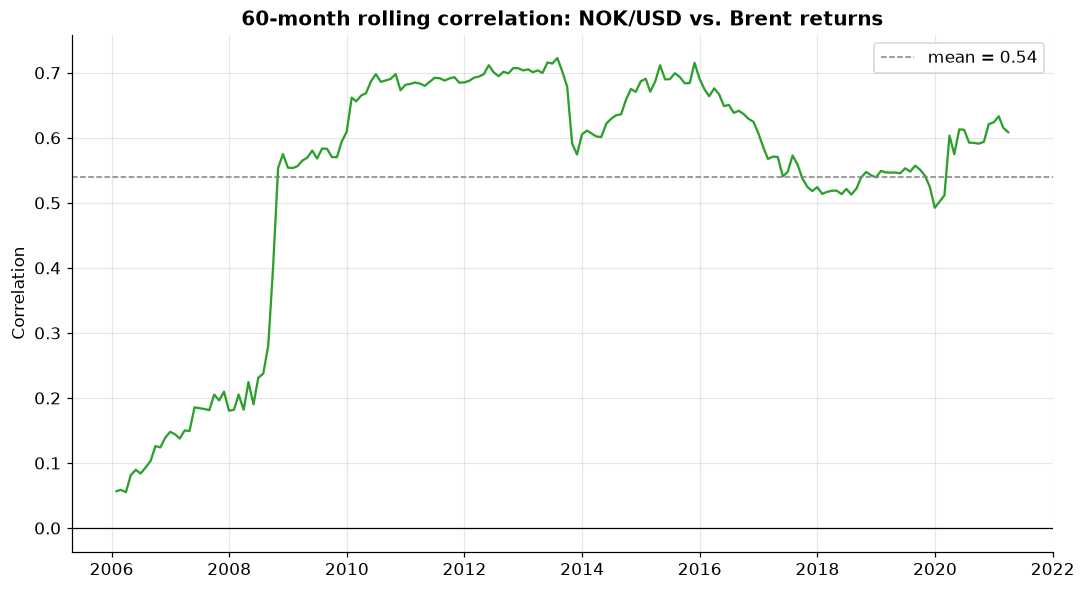

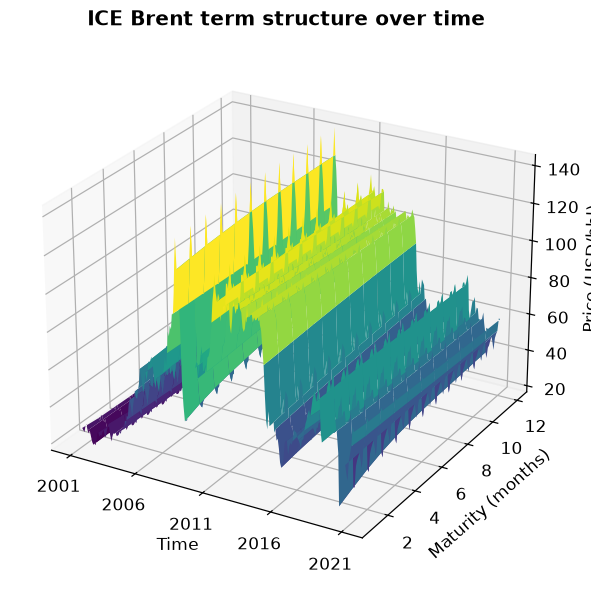

In [3]:
from src import eda
eda.run()
show("02_nokusd_vs_frontmonth.png", "02_rolling_corr_60m.png", "02_term_structure_3d.png")

## Step 3 — Diebold-Li factors

We compress the whole curve into three interpretable numbers per month:

$$ y(\tau) = \beta_1 + \beta_2\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_3\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right) $$

* **Level** ($\beta_1$): the whole curve up/down (≈ the oil price level).
* **Slope** ($\beta_2$): short vs. long end (contango/backwardation).
* **Curvature** ($\beta_3$): a mid-curve hump.

$\lambda$ is chosen by a grid search that minimises the fit error; the curvature
loading then peaks in the middle of our 1–12 month window.

[dl] Chosen lambda = 0.23  ->  curvature peak ~ 7.8 months
[dl] Average fit RMSE: 0.085 USD/bbl (mean price ~66)
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_factor_loadings.png


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_dl_factors.png
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\03_sample_fit.png
[dl] Saved factors to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\data\factors.parquet
[dl] corr(Level, M1) = 0.950


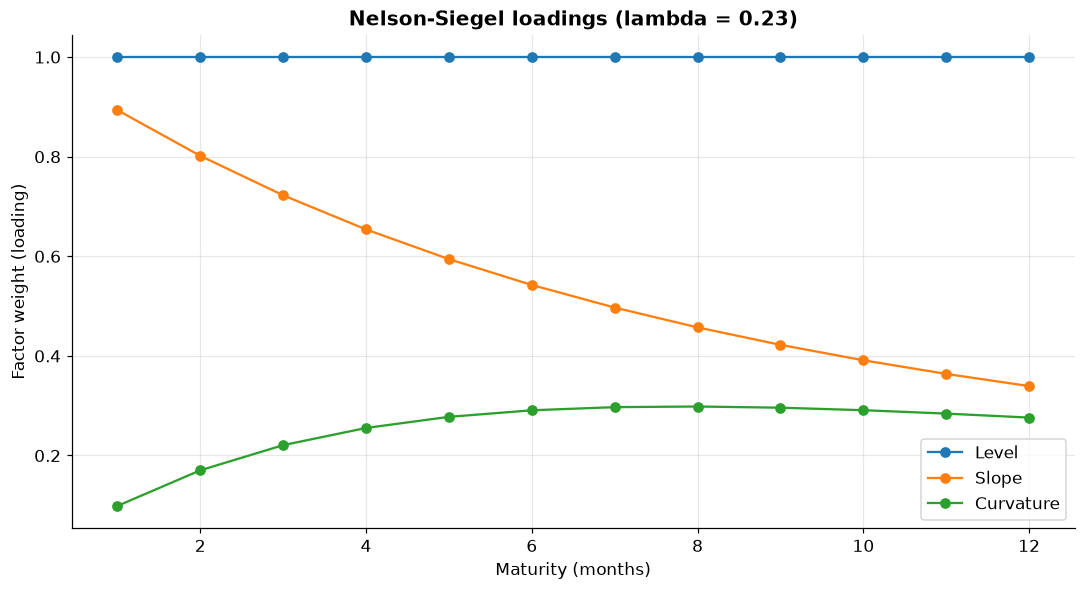

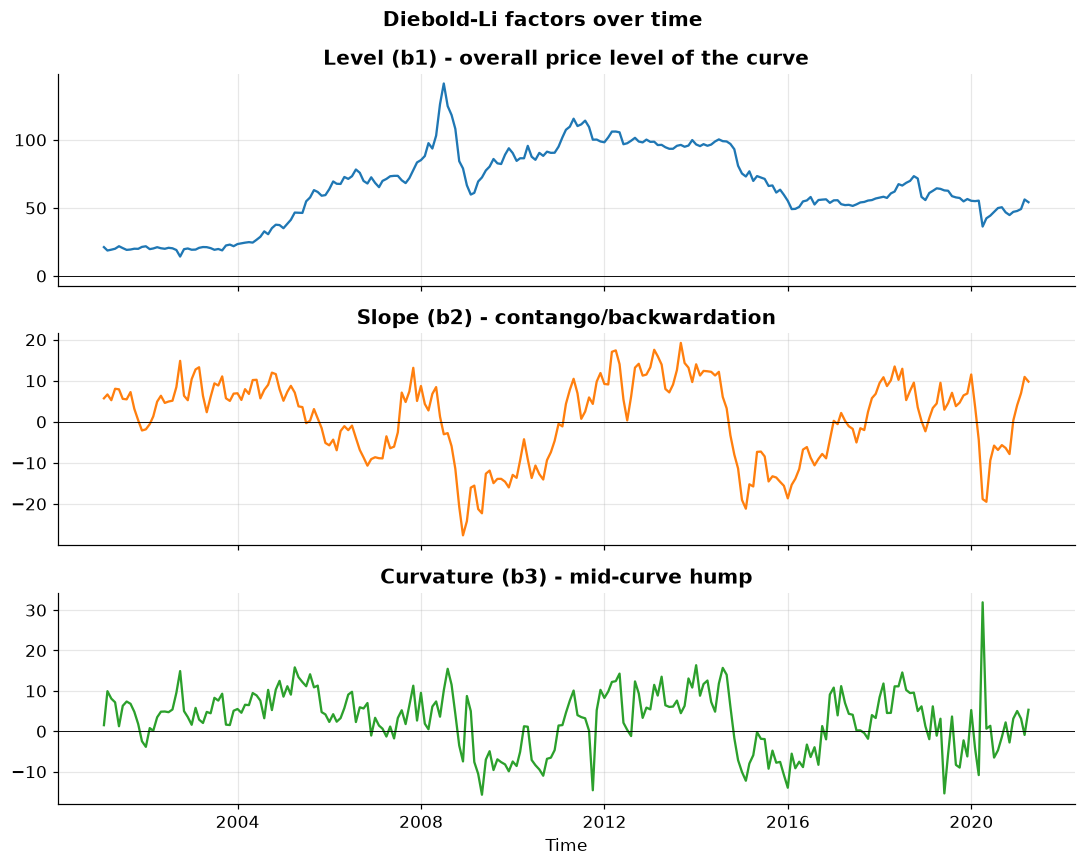

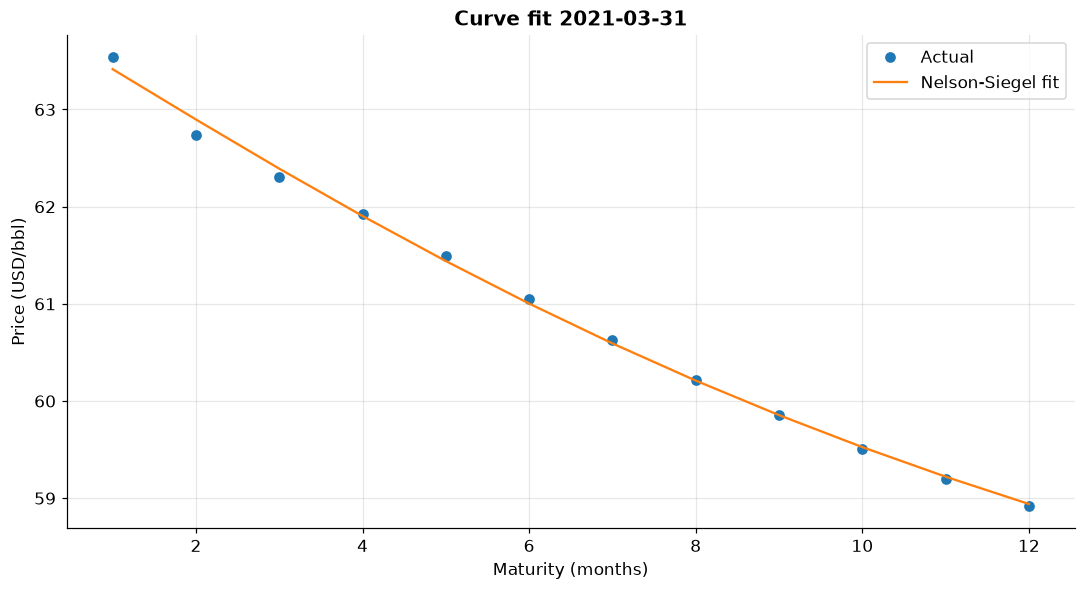

,Level,Slope,Curvature
date,,,
2001-01-31,21.154169,5.707558,1.509750
2001-02-28,18.663796,6.653857,9.921115
2001-03-31,19.274442,5.252150,8.076571
2001-04-30,19.972224,8.036444,7.167707
2001-05-31,21.810950,7.899744,1.241018


In [4]:
from src import diebold_li
factors = diebold_li.run()
show("03_factor_loadings.png", "03_dl_factors.png", "03_sample_fit.png")
factors.head()

## Step 4 — Rolling out-of-sample forecasts

We forecast the one-month **NOK/USD return** $r_{t+1} = (y_{t+1}-y_t)/y_t$
(simple, no logs) from information known at time $t$. Forecasting the return is
the natural framing for currency predictability: the random walk predicts a
**zero** return.

At each step the model is trained only on the past — no leakage. Models: simple/
multiple regression, AR(1), Elastic Net, a PyTorch LSTM, and an inverse-MSE
combination. Benchmarks: random walk with and without drift.

This is run under **two windowing schemes**:
* **expanding** (recursive): train on all past data;
* **rolling** (fixed 60 months): train on the most recent 60 months only.

*(The LSTM is retrained at every step; this cell takes ~1 minute for both schemes.)*

In [5]:
from src import forecasting
preds = forecasting.run()   # dict: {"expanding": df, "rolling": df}
preds["rolling"][["r_true", "Multiple", "Combination", "LSTM", "RW"]].head()

[fc:expanding] 2006-03-31  (OOS #1)


[fc:expanding] 2009-03-31  (OOS #37)


[fc:expanding] 2012-03-31  (OOS #73)


[fc:expanding] 2015-03-31  (OOS #109)


[fc:expanding] 2018-03-31  (OOS #145)


...

[fc:rolling] 2012-03-31  (OOS #73)


[fc:rolling] 2015-03-31  (OOS #109)


[fc:rolling] 2018-03-31  (OOS #145)


[fc:rolling] 2021-03-31  (OOS #181)
[fc:rolling] 181 OOS return forecasts saved to C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\forecasts_rolling.parquet


,r_true,Multiple,Combination,LSTM,RW
date,,,,,
2006-03-31,0.029361,-0.004315,0.002420,0.006563,0.0
2006-04-30,0.065191,-0.001794,0.003928,0.004256,0.0
2006-05-31,0.011196,0.006593,0.018796,0.063140,0.0
2006-06-30,-0.022217,0.004464,0.013231,0.037802,0.0
2006-07-31,0.009917,0.001211,0.000478,-0.018922,0.0


## Step 5 — Evaluation

RMSE vs. the random walk, CSSED over time, and the Diebold-Mariano test to decide
whether the differences are statistically significant — for **both** schemes, plus
a direct comparison.

In [6]:
from src import evaluation
evaluation.run()

[eval:expanding] 181 OOS forecasts (2006-03-31 -> 2021-03-31)
[eval:expanding] RMSE table (returns):
       model     RMSE  RMSE_rel_RW
         RW 0.034583     1.000000
   Multiple 0.034794     1.006098
   RW_drift 0.034832     1.007211
Combination 0.034923     1.009815
         AR 0.035031     1.012948
     Linear 0.035152     1.016453
 ElasticNet 0.035327     1.021504
       LSTM 0.042332     1.224054


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_pred_vs_true_expanding.png
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_cssed_expanding.png
[eval:expanding] DM vs RW (negative stat = better than RW):
       model  DM_stat_vs_RW  p_value_vs_RW
     Linear         2.1202         0.0354
   Multiple         0.3017         0.7632
         AR         1.3748         0.1709
 ElasticNet         1.7989         0.0737
       LSTM         3.6412         0.0004
Combination         0.6935         0.4889
[eval:rolling] 181 OOS forecasts (2006-03-31 -> 2021-03-31)
[eval:rolling] RMSE table (returns):
       model     RMSE  RMSE_rel_RW
   Multiple 0.034311     0.992138
         RW 0.034583     1.000000
Combination 0.034631     1.001399
   RW_drift 0.034751     1.004864
 ElasticNet 0.034975     1.011318
     Linear 0.035194     1.017656
         AR 0.035544     1.027797
       LSTM 0.042541     1.230116


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_pred_vs_true_rolling.png
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_cssed_rolling.png
[eval:rolling] DM vs RW (negative stat = better than RW):
       model  DM_stat_vs_RW  p_value_vs_RW
     Linear         1.7217         0.0868
   Multiple        -0.3230         0.7471
         AR         1.9236         0.0560
 ElasticNet         0.6447         0.5199
       LSTM         3.5087         0.0006
Combination         0.0886         0.9295
[eval] RMSE comparison (expanding vs rolling):
              expanding   rolling
model                           
Linear        0.035152  0.035194
Multiple      0.034794  0.034311
AR            0.035031  0.035544
ElasticNet    0.035327  0.034975
LSTM          0.042332  0.042541
Combination   0.034923  0.034631
RW            0.034583  0.034583
RW_drift      0.034832  0.034751


[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\05_rmse_compare.png


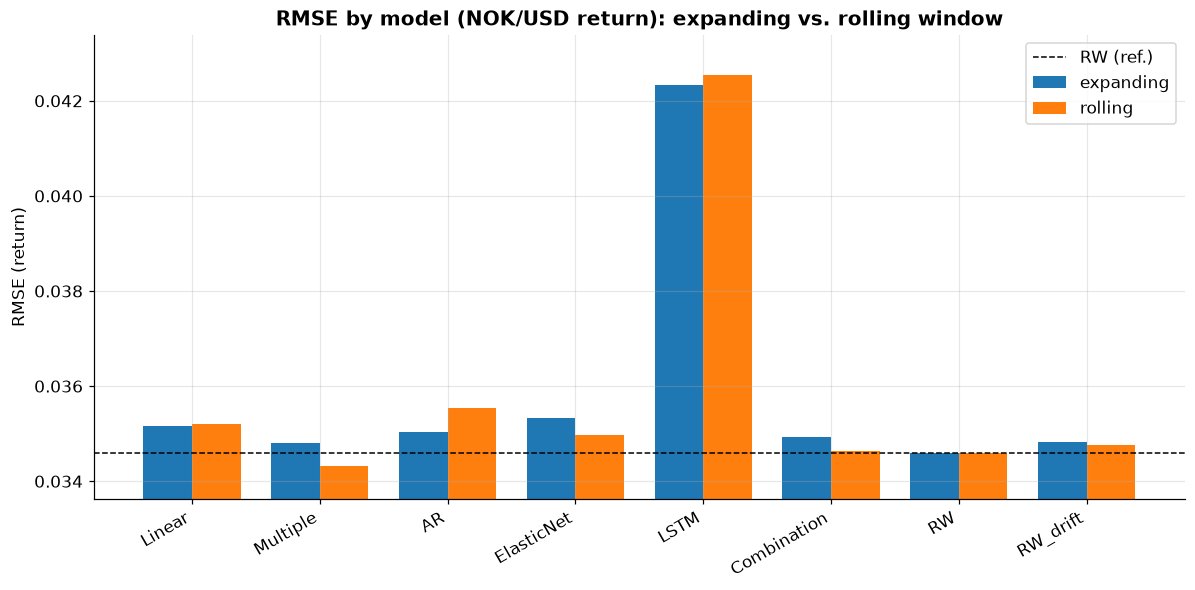

,expanding,rolling
model,,
Linear,0.035152,0.035194
Multiple,0.034794,0.034311
AR,0.035031,0.035544
ElasticNet,0.035327,0.034975
LSTM,0.042332,0.042541
Combination,0.034923,0.034631
RW,0.034583,0.034583
RW_drift,0.034832,0.034751


In [7]:
# Side-by-side RMSE: expanding vs rolling
show("05_rmse_compare.png")
show_csv("05_rmse_compare.csv").round(6)

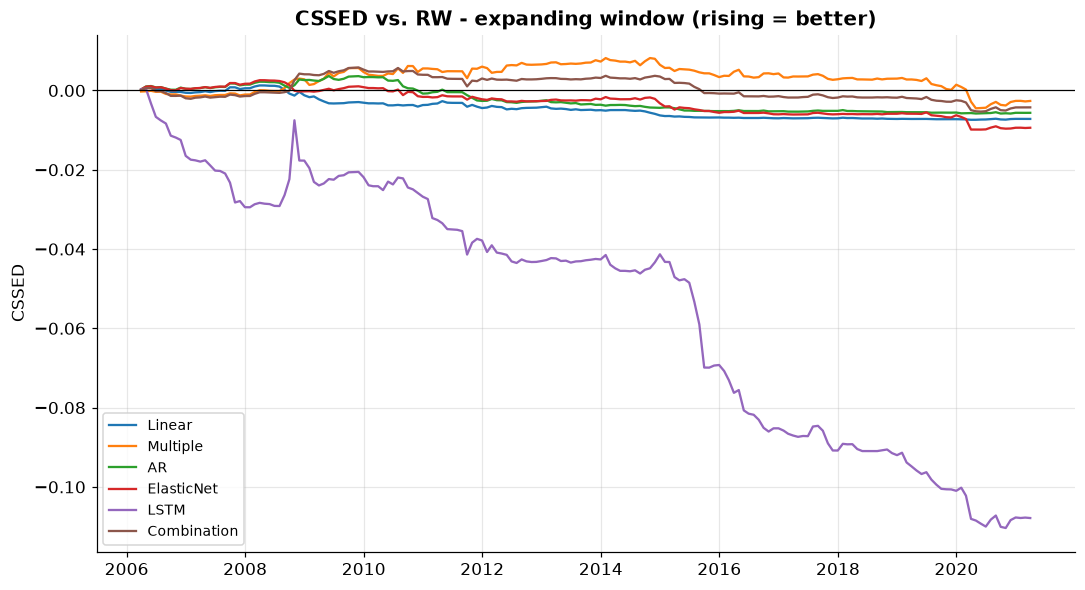

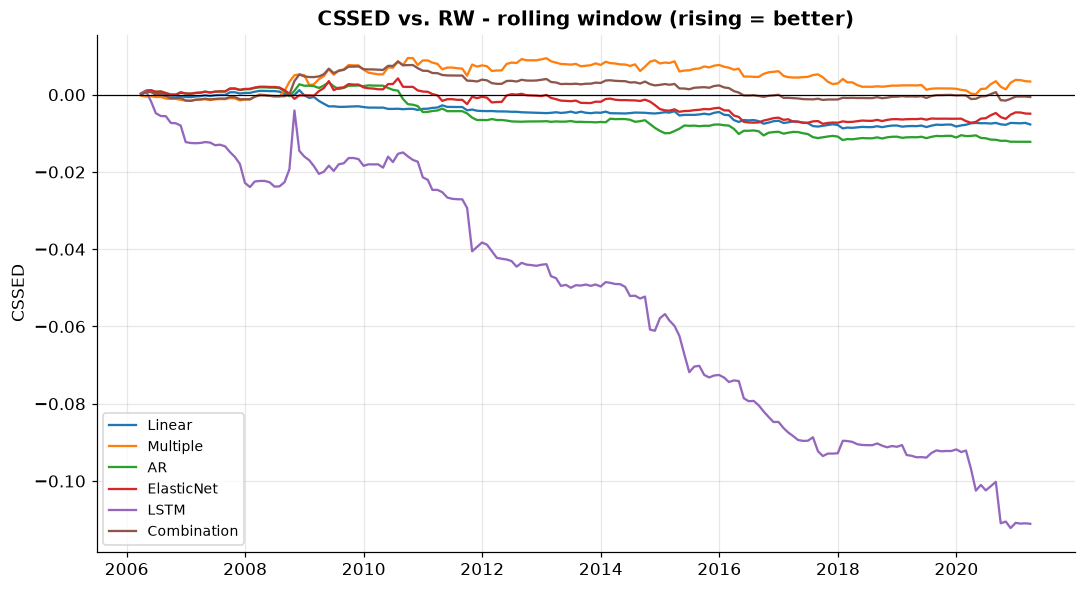

In [8]:
# CSSED vs random walk under both schemes
show("05_cssed_expanding.png", "05_cssed_rolling.png")

In [9]:
# Diebold-Mariano vs RW (negative stat = better than RW)
print("Expanding:")
display(show_csv("05_dm_vs_rw_expanding.csv", index_col=None).round(4))
print("Rolling:")
display(show_csv("05_dm_vs_rw_rolling.csv", index_col=None).round(4))

Expanding:


,model,DM_stat_vs_RW,p_value_vs_RW
0,Linear,2.1202,0.0354
1,Multiple,0.3017,0.7632
2,AR,1.3748,0.1709
3,ElasticNet,1.7989,0.0737
4,LSTM,3.6412,0.0004
5,Combination,0.6935,0.4889


Rolling:


,model,DM_stat_vs_RW,p_value_vs_RW
0,Linear,1.7217,0.0868
1,Multiple,-0.3230,0.7471
2,AR,1.9236,0.0560
3,ElasticNet,0.6447,0.5199
4,LSTM,3.5087,0.0006
5,Combination,0.0886,0.9295


**Finding:** No model beats the random walk *significantly* (DM). Under the
**rolling** window, `Multiple` and `Combination` edge just below RW on RMSE, while
the LSTM is significantly worse under both schemes. This is in line with
Meese–Rogoff: currencies are very hard to beat with a random walk.

## Step 6 — Profitability

A simple sign strategy: long/short the krone on the predicted direction. The
point — low RMSE and a profitable *direction* are not the same. The adaptive
(rolling) window improves almost everything.

[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\06_cumulative_returns_expanding.png
[trade:expanding] Strategy stats:
              total_return  ann_return  ann_vol  sharpe  hit_rate
Multiple            1.348       0.064    0.119   0.536     0.552
Combination         0.556       0.036    0.120   0.304     0.508
LSTM               -0.123      -0.002    0.120  -0.013     0.481
ElasticNet         -0.164      -0.005    0.120  -0.039     0.503
BuyHold            -0.211      -0.008    0.120  -0.071       NaN
AR                 -0.271      -0.014    0.120  -0.115     0.497
Linear             -0.443      -0.032    0.120  -0.263     0.486
[fig] C:\Users\jonas\Desktop\CCfolder\currency_forecasting\output\06_cumulative_returns_rolling.png
[trade:rolling] Strategy stats:
              total_return  ann_return  ann_vol  sharpe  hit_rate
Multiple            1.131       0.057    0.119   0.481     0.569
Combination         0.764       0.045    0.119   0.375     0.552
ElasticNet     

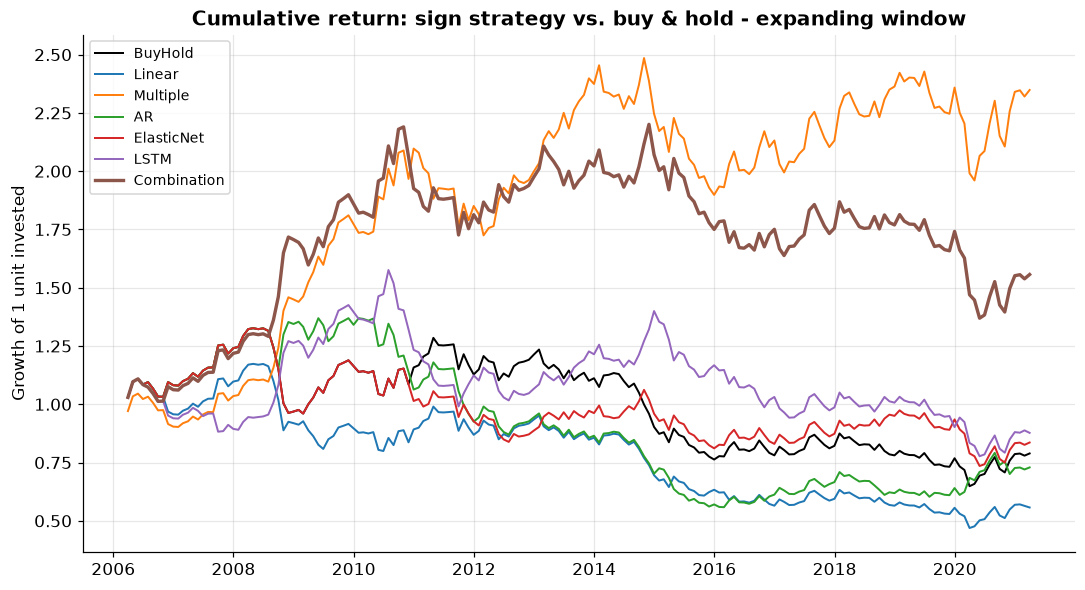

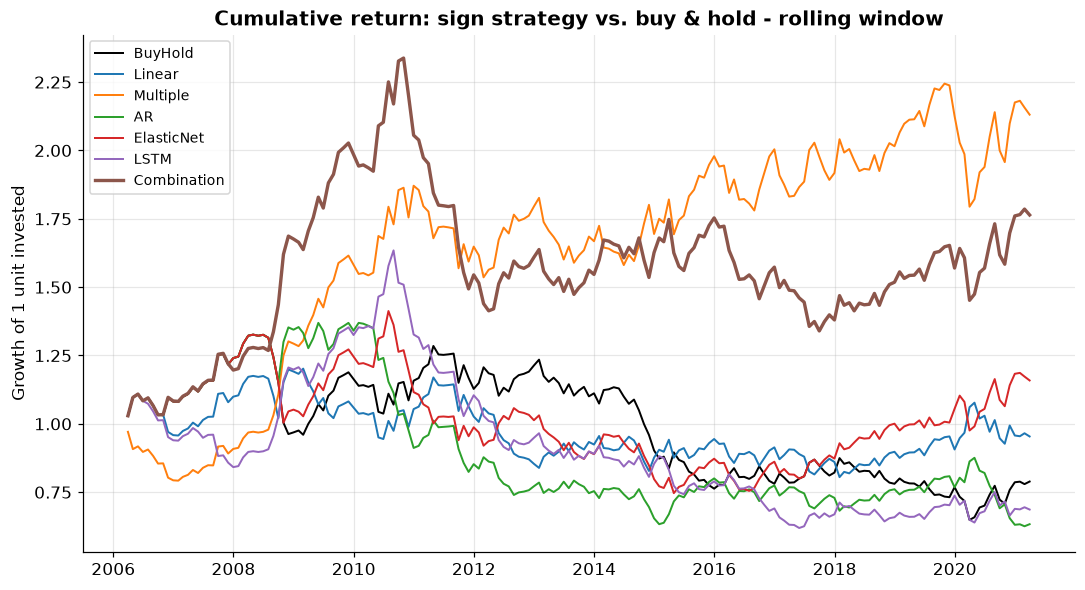

,expanding,expanding.1,expanding.2,rolling,rolling.1,rolling.2
NaN,total_return,sharpe,hit_rate,total_return,sharpe,hit_rate
Multiple,1.3480231540716856,0.536363588740234,0.5524861878453039,1.1307979004590605,0.48128230940775646,0.569060773480663
Combination,0.5564779867015519,0.3043514906667428,0.5082872928176796,0.7638759576552134,0.3745918376494136,0.5524861878453039
LSTM,-0.12285691849043501,-0.012713713084777372,0.48066298342541436,-0.31355933322309715,-0.1479266114785426,0.48066298342541436
ElasticNet,-0.16427109339948953,-0.0387694117916731,0.5027624309392266,0.1586548448585301,0.14159127807079822,0.5414364640883977
BuyHold,-0.21118305679212357,-0.07071422328368257,NaN,-0.21118305679212357,-0.07071422328368257,NaN
AR,-0.271170904303894,-0.11493459514270535,0.4972375690607735,-0.36721379337371995,-0.19285187230632392,0.5248618784530387
Linear,-0.4429920599813699,-0.2633229206726388,0.4861878453038674,-0.046218512151043334,0.03345772450564062,0.5193370165745856


In [10]:
from src import trading
trading.run()
show("06_cumulative_returns_expanding.png", "06_cumulative_returns_rolling.png")
show_csv("06_strategy_compare.csv", index_col=0).round(3)

## Conclusion

The term-structure factors carry a **weak but economically meaningful directional
signal** for the krone. They do not beat a random walk on pure forecast accuracy
(in line with the literature), but a directional strategy on the multiple
regression — especially with a rolling window — still beat buy & hold clearly.
Results are reported deliberately without overstatement.